# Full Pipeline Example: A + B → A...B → C...D → C + D

This notebook walks through the full `reaction_network_graph` pipeline: defining species, stages, and steps; building a `ReactionNetwork`; inspecting it; and rendering it to DOT/SVG.

The reaction `A + B -> C + D` is modeled as three elementary steps, each crossing a single transition state (a `Step`):

```
A + B  --TS1-->  [A...B]  --TS2-->  [C...D]  --TS3-->  C + D
```

`A+B` and `C+D` are *bimolecular* stages (two species each). `[A...B]` and `[C...D]` are *wells* - bound complexes, each treated as a single species in its own right, even though it's formed from two others.


In [6]:
from reaction_network_graph import (
    ReactionNetwork,
    Species,
    Stage,
    Step,
    to_dot,
    write_dot,
    write_svg,
)


## 1. Define species


In [7]:
species_a = Species(name="A")
species_b = Species(name="B")
species_c = Species(name="C")
species_d = Species(name="D")
species_ab = Species(name="AB")  # the bound A...B complex, as its own molecular entity
species_cd = Species(name="CD")  # the bound C...D complex

species_a, species_b, species_c, species_d, species_ab, species_cd


(Species(name='A', formula=None, charge=0, multiplicity=None, smiles=None),
 Species(name='B', formula=None, charge=0, multiplicity=None, smiles=None),
 Species(name='C', formula=None, charge=0, multiplicity=None, smiles=None),
 Species(name='D', formula=None, charge=0, multiplicity=None, smiles=None),
 Species(name='AB', formula=None, charge=0, multiplicity=None, smiles=None),
 Species(name='CD', formula=None, charge=0, multiplicity=None, smiles=None))

## 2. Define stages

A stage is a well (one species) or a bimolecular/termolecular channel (two or more species). `is_unimolecular` distinguishes the two - it's derived from `species`, not stored separately. Energies below are illustrative (arbitrary units, relative to `A+B = 0`).


In [8]:
reactants = Stage(name="A+B", species=[species_a, species_b], energy=0.0)
ab_complex = Stage(name="AB", species=[species_ab], energy=-5.0)
cd_complex = Stage(name="CD", species=[species_cd], energy=-8.0)
products = Stage(name="C+D", species=[species_c, species_d], energy=-3.0)

reactants.is_unimolecular, ab_complex.is_unimolecular


(False, True)

## 3. Define steps (transition states)

A `Step` is the transition state itself - it doesn't know which two stages it connects; that's determined entirely by where it's placed when the network is built. That's why the same `Step` payload could later be rewired to a different pair of stages without being reconstructed.


In [9]:
ts1 = Step(name="TS1", energy=1.0)  # A+B -> A...B: entrance barrier
ts2 = Step(name="TS2", energy=-2.0)  # A...B -> C...D: the actual rearrangement
ts3 = Step(name="TS3", energy=-1.0)  # C...D -> C+D: exit barrier

ts1, ts2, ts3


(Step(name='TS1', label=None, energy=1.0),
 Step(name='TS2', label=None, energy=-2.0),
 Step(name='TS3', label=None, energy=-1.0))

`ReactionNetwork.build()` takes a list of `(stage_a, stage_b, step)` triples and validates everything (unique names, no self-loops, no conflicting duplicate stages) up front. A stage that recurs across multiple triples - like `ab_complex` below, which is both the destination of `ts1` and the source of `ts2` - is deduplicated automatically. Stages with no steps at all can be added via the separate `stages=` argument.

In [ ]:
network = ReactionNetwork.build(
    [
        (reactants, ab_complex, ts1),
        (ab_complex, cd_complex, ts2),
        (cd_complex, products, ts3),
    ]
)

## 5. Inspect the network


In [11]:
print("Stages:", network.stage_names())
print()
for stage_a, stage_b, step in network.steps():
    print(f"{stage_a!r} -- {step.name} --> {stage_b!r}")


Stages: ['A+B', 'AB', 'CD', 'C+D']

'A+B' -- TS1 --> 'AB'
'AB' -- TS2 --> 'CD'
'CD' -- TS3 --> 'C+D'


In [12]:
# Which steps touch the "A...B" well, and what's on the other side of each?
list(network.steps_at("A...B"))


[]

## 6. Render to DOT

Stages become pink circles, steps become blue squares sitting *between* the two stages they connect, and each stage's species are drawn as small orange satellite nodes.


In [13]:
print(to_dot(network))


graph reaction_network {
layout=neato;
overlap=false;
splines=true;
node [fontname=Helvetica];
"A+B" [label="A+B\n(0.0)", shape=circle, style=filled, fillcolor="#df8bbb"];
"A+B__species0" [label=A, shape=circle, style=filled, fillcolor="#fc8d62"];
"A+B" -- "A+B__species0" [color=black, penwidth=1];
"A+B__species1" [label=B, shape=circle, style=filled, fillcolor="#fc8d62"];
"A+B" -- "A+B__species1" [color=black, penwidth=1];
"AB" [label="AB\n(-5.0)", shape=circle, style=filled, fillcolor="#df8bbb"];
"AB__species0" [label=AB, shape=circle, style=filled, fillcolor="#fc8d62"];
"AB" -- "AB__species0" [color=black, penwidth=1];
"CD" [label="CD\n(-8.0)", shape=circle, style=filled, fillcolor="#df8bbb"];
"CD__species0" [label=CD, shape=circle, style=filled, fillcolor="#fc8d62"];
"CD" -- "CD__species0" [color=black, penwidth=1];
"C+D" [label="C+D\n(-3.0)", shape=circle, style=filled, fillcolor="#df8bbb"];
"C+D__species0" [label=C, shape=circle, style=filled, fillcolor="#fc8d62"];
"C+D" -- "C+D_

## 7. Write DOT and SVG files

`write_dot()` writes the raw DOT text; `write_svg()` renders straight to SVG via Graphviz (`dot` must be on `PATH` - it's provided by the `graphviz` pixi dependency). Both are written next to this notebook.


In [14]:
write_dot(network, "network.dot")
write_svg(network, "network.svg")


## 8. Display the rendered SVG inline


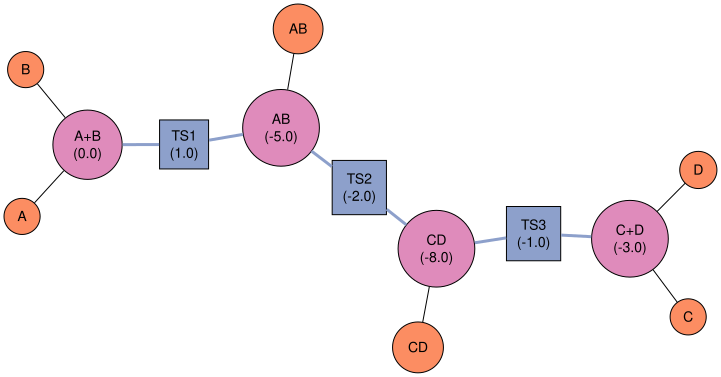

In [15]:
from IPython.display import SVG, display

display(SVG("network.svg"))


---

From here, `network.svg` is ready to open and edit by hand (e.g. in Inkscape) for a paper figure. Colors/shapes are module-level constants in `reaction_network_graph.dot` if you want to change the defaults for a particular figure.
